# Bayesian Optimization Workflow

Bayesian optimization (BO) is a statistical technique that is used in machine learning to find the best hyperparameters necessary for training. The parameter search can typically be searched randomly for the parameters to use for training, but this can be cost and time-intensive depending on the application. BO can vastly decrease the time needed to find the optimal hyperparameters. <br> 
In this workflow, mathematical equations with 2 inputs can be modeled, and BO is able to find their global optima.

The process for BO follows:
1. Select the objective function: the function you want to optimize (I focused on maximization for this code)
2. Randomly choose the first initial point(s) 
3. Choose a surrogate model to imitate the analytical function and predict the output from the candidates. Gaussian process is a great one to use as it is a non-parametric model and even works well in small datasets. It gives predictions for both mean and variance which is ideal for this process.
4. Select an acquisition function that is used for finding the next best inputs. A few common ones are expected improvement (EI), upper confidence bound (UCB), and probability of improvement (PI). EI is a good one to start with as it is a good balance between exploration and exploitation. Use the function to choose the next candidate. 
5. Add the next candidate to your list of inputs and evaluate objective function at that point.
6. Update the surrogate model with the new observation and calculate performance of each iteration 
7. Repeat process for a certain number of iterations 
8. Analyze the points and see how well the outputs are compared to the true global optima of the objective function.

First, lets start the code, load the objective function, and make a surface plot to visualize it.

In [ ]:
# Import necessary libraries
from functions import functions
import torch
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import math
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.acquisition.monte_carlo import qExpectedImprovement, qProbabilityOfImprovement
from botorch.acquisition.analytic import UpperConfidenceBound
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.optim import optimize_acqf
import warnings
from botorch.optim.initializers import BadInitialCandidatesWarning
from botorch.models.utils.assorted import InputDataWarning
warnings.filterwarnings("ignore", category=BadInitialCandidatesWarning)
warnings.filterwarnings("ignore", category=InputDataWarning)
warnings.filterwarnings("ignore", category=UserWarning)  
%matplotlib inline

The objective function and its metadata (domain and optima) are loaded from files called functions.json and functions.py. If you want to try other equations or your own ML model, feel free to edit those files so they can be used here. The ones in the current list are simple mathematical equations with clear global max/min values. I made all of the functions have a global maxmimum so it is easier for the code to work with.

In [12]:
# Load metadata of the function based on the desired one
with open("functions.json", "r") as f:
    func_data = json.load(f)
name = "Sphere"  # change this!
for f in func_data["functions"]:
        if f["name"] == name:
            func_info = f
x1_min, x1_max = func_info["domain"]["x1"]
x2_min, x2_max = func_info["domain"]["x2"]
optima = func_info["optima"]["value"]
func = getattr(functions, func_info["name"].lower())

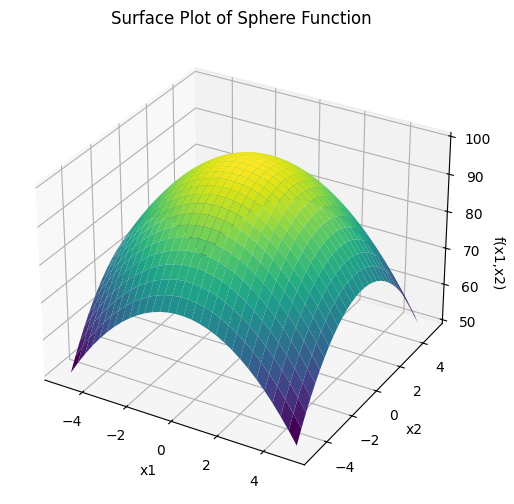

In [42]:
# Make surface plot to visualize function in a 3D space
x1 = np.linspace(x1_min,x1_max, 30)   
x2 = np.linspace(x2_min,x2_max, 30)
X1, X2 = np.meshgrid(x1, x2)
Z = func(np.column_stack([X1.ravel(), X2.ravel()])).reshape(X1.shape)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none')
ax.set_title(f"Surface Plot of {name} Function")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.text2D(1.04, 0.5, "f(x1,x2)",transform=ax.transAxes, rotation=270, va='center', ha='left')
plt.show()

This is where the actual BO process begins. The parameters can be changed, I used 1 initial point and 10 experiments to start.

In [ ]:
# Initialize seed and optimization parameters
np.random.seed(123)
initial_points = 1
experiments = 10
mc_samples = 1024
perf_list = []
bounds = torch.tensor([[x1_min, x2_min], [x1_max, x2_max]], dtype=torch.float)
point1 = x1_min + (x1_max - x1_min) * torch.rand(initial_points)
point2 = x2_min + (x2_max - x2_min) * torch.rand(initial_points)
X_train = torch.stack([point1,point2],dim=1)
Y_train = func(X_train.numpy())
Y_train = torch.tensor(Y_train).unsqueeze(-1)
for i in range(initial_points, experiments):
    print(f'Experiment {i}:')
    # Fit Gaussian Process surrogate model
    gp = SingleTaskGP(X_train, Y_train)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    sampler = SobolQMCNormalSampler(sample_shape=torch.Size([mc_samples]))
    best_f = Y_train.max()
    # set up Expected Improvement acquisition function using gaussian process and optimize it
    # feel free to try other acquisition functions
    ei = qExpectedImprovement(model=gp, best_f=best_f.item(), sampler=sampler)  
    bounds = torch.tensor([[x1_min, x2_min], [x1_max, x2_max]], dtype=torch.float)
    X_next,j = optimize_acqf(ei,bounds=bounds,q=1,num_restarts=5,raw_samples=128,options={"batch_limit": 5, "maxiter": 200})
    Y_next = torch.tensor(func(X_next.numpy())).unsqueeze(-1)
    print(f'Next point: {X_next}')
    print(f'Next output: {Y_next}')
    # Update training data
    X_train = torch.cat([X_train, X_next], dim=0)
    Y_train = torch.cat([Y_train, Y_next], dim=0)
    perf = float(Y_next)/float(optima)
    perf_list.append(perf)
    print(f'Performance: {perf}')
best_val, best_idx = torch.max(Y_train.squeeze(-1), dim=0)
best_point = X_train[best_idx]
candidates = X_train.numpy().tolist()

Experiment 1:


C:\Users\tarun\Anaconda3\new\envs\BO\Lib\site-packages\botorch\acquisition\monte_carlo.py:400: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Next point: tensor([[-3.7147, -2.2004]])
Next output: tensor([[81.3591]])
Performance: 0.8135911560058594
Experiment 2:


C:\Users\tarun\Anaconda3\new\envs\BO\Lib\site-packages\botorch\acquisition\monte_carlo.py:400: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
C:\Users\tarun\Anaconda3\new\envs\BO\Lib\site-packages\botorch\optim\optimize.py:753: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


Next point: tensor([[ 0.1280, -1.2660]])
Next output: tensor([[98.3810]])
Performance: 0.9838095855712891
Experiment 3:


...

Next point: tensor([[0.2514, 0.0366]])
Next output: tensor([[99.9355]])
Performance: 0.9993547058105469
Experiment 8:


C:\Users\tarun\Anaconda3\new\envs\BO\Lib\site-packages\botorch\acquisition\monte_carlo.py:400: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Next point: tensor([[0.0765, 0.0076]])
Next output: tensor([[99.9941]])
Performance: 0.9999409484863281
Experiment 9:


C:\Users\tarun\Anaconda3\new\envs\BO\Lib\site-packages\botorch\acquisition\monte_carlo.py:400: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Next point: tensor([[5.0000, 1.5891]])
Next output: tensor([[72.4749]])
Performance: 0.72474853515625


The performance (output / max) is plotted to show how strong each iteration of the BO loop is. In the sphere case, it took only 3 iterations to achieve a perfect performance, showing that the optimization was very quick.

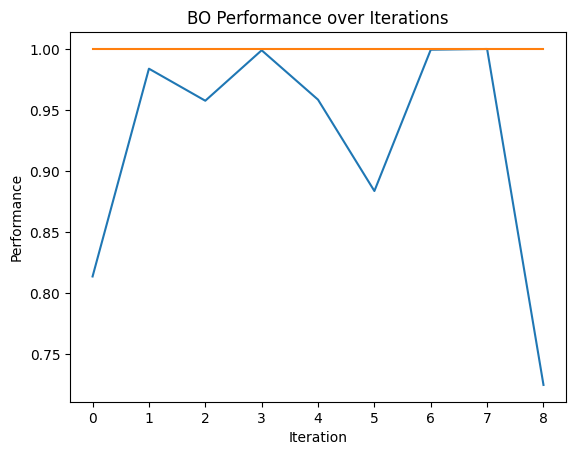

In [17]:
plt.plot(range(len(perf_list)), perf_list)
plt.plot(np.ones(len(perf_list)))
plt.xlabel("Iteration")
plt.ylabel("Performance")
plt.title("BO Performance over Iterations")
plt.show()


Plot the BO campaign. 

The contour plot shows the surface plot from earlier on a 2D space, where the topography shows the evaluation of the function at all the points, illustrated by color. The initial point, all the outputs from BO, and the optima is shown.

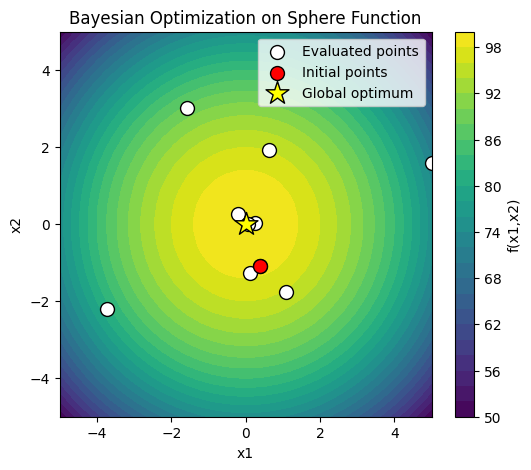

In [24]:
# Can use the x1, x2 definition from earlier
# x1 = np.linspace(x1_min, x1_max, 50)
# x2 = np.linspace(x2_min, x2_max, 50)
# X1, X2 = np.meshgrid(x1, x2)

all_pts = np.array(candidates)
init_pts = all_pts[:initial_points]
Z = func(np.column_stack([X1.ravel(), X2.ravel()])).reshape(X1.shape)
plt.figure(figsize=(6,5))
plt.contourf(X1, X2, Z, levels=30, cmap='viridis')
plt.colorbar(label='f(x1,x2)')
plt.scatter(all_pts[:,0], all_pts[:,1], color='white', edgecolor='black', s=100, label='Evaluated points')
plt.scatter(init_pts[:,0], init_pts[:,1], color='red', edgecolor='black', s=100, label='Initial points')
plt.scatter(0, 0, color='yellow', marker='*', s=300, edgecolor='black', label='Global optimum')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Bayesian Optimization on Sphere Function')
plt.legend()
plt.show()
